# Mojito Processing Pipeline

Demonstrates the full TDI data processing pipeline using the `process_pipeline` utility from `MojitoProcessor`.

The pipeline applies the following steps in order:

| Step | Operation | Default |
|------|-----------|------|
| 1 | Band-pass filter | configurable (f_low, f_high), order |
| 2 | Trim edge artefacts | 2.2% from each end |
| 3 | Truncate to working length | configurable |
| 4 | Downsample | configurable target rate |
| 5 | Tukey window | α = 0.025 |

The final cell verifies consistency by comparing the periodogram against the Mojito L1 noise estimate.

In [2]:
import logging
import numpy as np
import matplotlib.pyplot as plt

from mojito import MojitoL1File
from MojitoProcessor import process_pipeline
from MojitoProcessor.SigProcessing import planck_window


# Show pipeline progress at INFO level
logging.basicConfig(
    level=logging.INFO,
    format="%(name)s | %(message)s",
)

ModuleNotFoundError: No module named 'MojitoProcessor.SigProcessing'

## 1. Load Data

In [ ]:
day = 24*3600

noise_fl = '/Users/stas/Projects/LISA/Mojito/Noise/NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5'

mojito_data_file = (
    noise_fl
)

# ── How many days to load (lazy slicing — only reads what is needed) ───────────
load_days = None  # set to None to load the full dataset

with MojitoL1File(mojito_data_file) as f:
    tdi_sampling = f.tdis.time_sampling
    ltt_sampling = f.ltts.time_sampling
    orbit_sampling = f.orbits.time_sampling

    # Consistent sample counts across all data streams
    n_tdi = int(load_days * 86400 * tdi_sampling.fs) if load_days else tdi_sampling.size
    n_ltt = int(load_days * 86400 * ltt_sampling.fs) if load_days else ltt_sampling.size
    n_orbit = (
        int(load_days * 86400 * orbit_sampling.fs) if load_days else orbit_sampling.size
    )

    data = {
        # ── TDI observables ──────────────────────────────────────────────────
        "tdis": {
            "X": f.tdis.x2[:n_tdi],
            "Y": f.tdis.y2[:n_tdi],
            "Z": f.tdis.z2[:n_tdi],
            "A": f.tdis.a2[:n_tdi],
            "E": f.tdis.e2[:n_tdi],
            "T": f.tdis.t2[:n_tdi],
        },
        "fs": tdi_sampling.fs,
        "dt": tdi_sampling.dt,
        "t_tdi": tdi_sampling.t()[:n_tdi],
        # ── Light travel times ───────────────────────────────────────────────
        "ltts": {
            "12": f.ltts.ltt_12[:n_ltt],
            "13": f.ltts.ltt_13[:n_ltt],
            "21": f.ltts.ltt_21[:n_ltt],
            "23": f.ltts.ltt_23[:n_ltt],
            "31": f.ltts.ltt_31[:n_ltt],
            "32": f.ltts.ltt_32[:n_ltt],
        },
        "ltt_derivatives": {
            "12": f.ltts.ltt_derivative_12[:n_ltt],
            "13": f.ltts.ltt_derivative_13[:n_ltt],
            "21": f.ltts.ltt_derivative_21[:n_ltt],
            "23": f.ltts.ltt_derivative_23[:n_ltt],
            "31": f.ltts.ltt_derivative_31[:n_ltt],
            "32": f.ltts.ltt_derivative_32[:n_ltt],
        },
        "ltt_times": ltt_sampling.t()[:n_ltt],
        # ── Spacecraft orbits ────────────────────────────────────────────────
        "orbits": f.orbits.positions[:n_orbit],  # (n_orbit, 3, 3)
        "velocities": f.orbits.velocities[:n_orbit],  # (n_orbit, 3, 3)
        "orbit_times": orbit_sampling.t()[:n_orbit],
        # ── Noise estimates (frequency-domain, not truncated) ────────────────
        "noise_estimates": {
            "xyz": f.noise_estimates.xyz[:],
            "aet": f.noise_estimates.aet[:],
            "freqs": f.noise_estimates.freq_sampling.f(),
        },
        # ── Metadata ─────────────────────────────────────────────────────────
        "metadata": {
            "laser_frequency": f.laser_frequency,
            "pipeline_name": f.pipeline_names,
        },
    }

n_samples = len(data["tdis"]["X"])
duration = n_samples * data["dt"]
print(f"Loaded: {n_samples:,} samples @ {data['fs']} Hz ({duration / 86400:.2f} days)")
print(f"TDI channels: {list(data['tdis'].keys())}")

Loaded: 25,246,480 samples @ 0.4 Hz (730.51 days)
TDI channels: ['X', 'Y', 'Z', 'A', 'E', 'T']


In [ ]:
print (data["t_tdi"]/day)

[1131.13356282 1131.13359176 1131.13362069 ... 1861.64505009 1861.64507902
 1861.64510796]


## 2. Run the Processing Pipeline

All pipeline parameters are configurable here. The pipeline runs in this order:

```
bandpass/highpass filter → downsample → trim → truncate → window
```

We remark that the time-domain data will be normalised by the central frequency of the laser through the processing pipeline. The units are thus dimensionless. 

In [ ]:
# ── Pipeline parameters ───────────────────────────────────────────────────────

# Downsampling parameters
downsample_kwargs = {
    "target_fs": 0.2,  # Hz — target sampling rate (None = no downsampling).
    "kaiser_window": 31.0,  # Kaiser window beta parameter (higher = more aggressive anti-aliasing)
}

# Filter parameters
filter_kwargs = {
    "highpass_cutoff": 1e-5,  # Hz — high-pass cutoff (always applied)
    "lowpass_cutoff": 0.5
    * downsample_kwargs[
        "target_fs"
    ],  # Hz — low-pass cutoff (set None for high-pass only)
    "order": 2,  # Butterworth filter order
}

# Trim parameters
trim_kwargs = {
    "fraction": 0.02,  # Fraction of post-downsample duration trimmed from each end.
    # Total amount of data remaining is (1 - fraction) * N, for N
    # the number of samples after downsampling.
}

# Segmentation parameters
truncate_kwargs = {
    "days": 120.0,  # Segment length in days (splits dataset into 7-day chunks)
}

# Window parameters
window_kwargs = {
    # "window": "tukey",  # Window type: 'tukey', 'hann', 'hamming', 'blackman'
    # "alpha": 0.0125,  # Taper fraction for Tukey window
    "window": "planck",  # Window type: 'tukey', 'hann', 'hamming', 'blackman'
    "alpha": 0.05,  # Taper fraction for Tukey window
}
# ─────────────────────────────────────────────────────────────────────────────

processed_segments = process_pipeline(
    data,
    downsample_kwargs=downsample_kwargs,
    filter_kwargs=filter_kwargs,
    # trim_kwargs=trim_kwargs,
    truncate_kwargs=truncate_kwargs,
    window_kwargs=window_kwargs,
)

# For the rest of the notebook, use the first segment
sp_0 = processed_segments["segment0"]

MojitoProcessor.SigProcessing | Step 1/5 | Init: 25246480 samples @ 0.4 Hz (730.51 days), channels=['X', 'Y', 'Z']
MojitoProcessor.SigProcessing | Step 2/5 | Band-pass: [1.0e-05, 1.0e-01] Hz, order=2 (zero-phase Butterworth)
MojitoProcessor.SigProcessing | Step 3/5 | Resample: 0.4 Hz → 0.2 Hz, 25246480 → 12623240 samples (Nyquist = 0.1 Hz)
MojitoProcessor.SigProcessing | Step 4/5 | Trim: 0.00% from each end → 12623240 samples (730.51 days)
MojitoProcessor.SigProcessing | Step 5/5 | Segment: created 6 segments × 120.00 days each | Window: planck (alpha=0.05)


In [ ]:


print (processed_segments.keys())

print (sp_0)
print (sp_0.data.keys())
print (sp_0.dt, sp_0.fs)
print (sp_0.t0, sp_0.t0/day)

tm = sp_0.t0 + np.arange(sp_0.N)*sp_0.dt
dt = sp_0.dt 
fs = sp_0.fs

dict_keys(['segment0', 'segment1', 'segment2', 'segment3', 'segment4', 'segment5'])
SignalProcessor(channels=['X', 'Y', 'Z'], N=2073600, fs=0.200 Hz, T=10368000.00 s, t0=9.77299e+07 s)
dict_keys(['X', 'Y', 'Z', 't'])
5.0 0.2
97729939.827664 1131.1335628201853


In [ ]:
# def planck_window(N, epsilon=0.1):
#     """
#     Construct a Planck-taper window of length N.
    
#     Parameters
#     ----------
#     N : int
#         Number of points in the window.
#     epsilon : float, optional
#         Fraction of the window length to taper at each end. 
#         Must be between 0 and 0.5. Default is 0.1.
        
#     Returns
#     -------
#     w : numpy.ndarray
#         The window function of length N.
#     """
#     # Ensure epsilon is within valid bounds
#     epsilon = np.clip(epsilon, 1e-9, 0.5)
    
#     n = np.arange(N)
#     w = np.zeros(N)
    
#     # Define the transition regions
#     n1 = epsilon * (N - 1)
#     n2 = (1 - epsilon) * (N - 1)
    
#     # Region 1: Rising taper (0 <= n < n1)
#     mask1 = (n < n1)
#     z1 = np.where(mask1, epsilon * (N - 1) / (n + 1e-15) + epsilon * (N - 1) / (n - epsilon * (N - 1) + 1e-15), 0.0)
#     # w = np.where(mask1, 1.0 / (1.0 + np.exp(z1)), w)
#     z1 = np.clip(z1, -700.0, 700.0)
#     w = np.where(mask1, 1.0 / (1.0 + np.exp(z1)), w)
    
#     # Region 2: Flat top (n1 <= n <= n2)
#     mask2 = (n >= n1) & (n <= n2)
#     w = np.where(mask2, 1.0, w)
    
#     # Region 3: Falling taper (n2 < n < N)
#     mask3 = (n > n2)
#     z2 = np.where(mask3, epsilon * (N - 1) / (N - 1 - n + 1e-15) + epsilon * (N - 1) / (N - 1 - n - epsilon * (N - 1) + 1e-15), 0.0)
#     z2 = np.clip(z2, -700.0, 700.0)
#     w = np.where(mask3, 1.0 / (1.0 + np.exp(z2)), w)
    
#     return w

In [ ]:
from scipy import signal

win = planck_window(sp_0.N, 0.05)

fg10, ax = plt.subplots(3, figsize=(10, 6), sharex=True)
plt.subplots_adjust(hspace=0.3)
ax[0].plot(tm/day, sp_0.data["X"]*win, label="X")

# ax[0].set_title("TDI X, Y, Z")
# ax[0].set_xlabel("Time (days)")
# ax[0].set_ylabel("Strain")
# ax[0].legend()

ax[1].plot(tm/day, sp_0.data["Y"], label="Y")
ax[2].plot(tm/day, sp_0.data["Z"], label="Z")

plt.show()


win2 = signal.windows.tukey(sp_0.N, alpha=0.0125)
# win = win2

print (win.shape, win2.shape, sp_0.N)

plt.plot(np.arange(sp_0.N), win, label="Planck Window")
plt.plot(np.arange(sp_0.N), win2, label="Tukey Window")
plt.legend()
plt.title("Comparison of Planck and Tukey Windows")
plt.xlabel("Sample Index")
plt.ylabel("Window Value")
plt.axis([0, 50_000, 0, 1.1])
plt.show()


NameError: name 'planck_window' is not defined

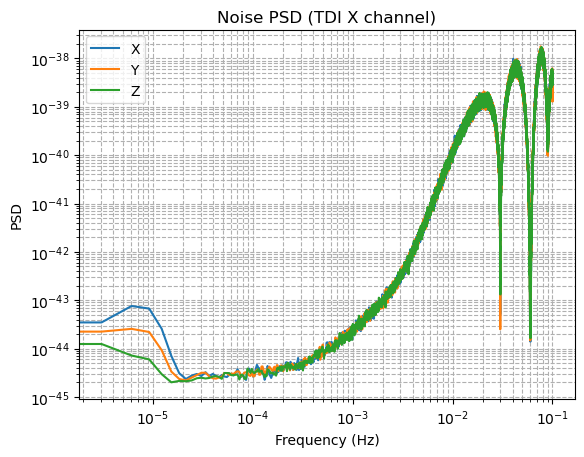

In [ ]:
from scipy.signal import welch



f_psdX, psdX = welch(sp_0.data["X"]*win, fs=fs, nperseg=16*4096, window="hann")
f_psdY, psdY = welch(sp_0.data["Y"]*win, fs=fs, nperseg=16*4096, window="hann")
f_psdZ, psdZ = welch(sp_0.data["Z"]*win, fs=fs, nperseg=16*4096, window="hann")


plt.loglog(f_psdX, psdX, label="X")
plt.loglog(f_psdY, psdY, label="Y")
plt.loglog(f_psdZ, psdZ, label="Z")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Noise PSD (TDI X channel)")
plt.grid(which="both", ls="--")
plt.legend()
plt.show()

### whitening the data

In [ ]:
from scipy.interpolate import interp1d
Welch_interpX = interp1d(f_psdX, psdX, kind='linear', fill_value='extrapolate')

print (Welch_interpX(f_psdX))



def WitenData(Dat, Welch_interp, win):
    
    # win = planck_window(len(Dat), eps)
    DXf2 = np.fft.rfft(win*Dat)
    # DXf2 = np.fft.rfft(Dat)
    freqs = np.fft.rfftfreq(len(Dat), dt)
    # print (freqs)

    DXf_white = np.zeros_like(DXf2)

    psd_vals = Welch_interp(freqs)
    DXf_white = np.array(DXf2/np.sqrt(psd_vals))

    # win_freq = tr.planck_window_asymmetric(len(freqs), epsilonL=0.001, epsilonR=0.00001)

    # DXf_white = DXf_white*win_freq
    # plt.loglog(freqs, np.abs(DXf_white))
    # plt.show()

    DXt_white = np.fft.irfft(DXf_white)
    # win = tr.planck_window(len(DXt_white), 0.001)

    # return win*DXt_white
    return DXt_white

[1.64707975e-44 3.48166512e-44 7.61510665e-44 ... 3.43172886e-39
 3.10390589e-39 1.78423171e-39]


In [ ]:
X_white = WitenData(sp_0.data["X"], Welch_interpX, win)

f_psdXw, psdXw = welch(X_white, fs=fs, nperseg=16*4096, window="hann")

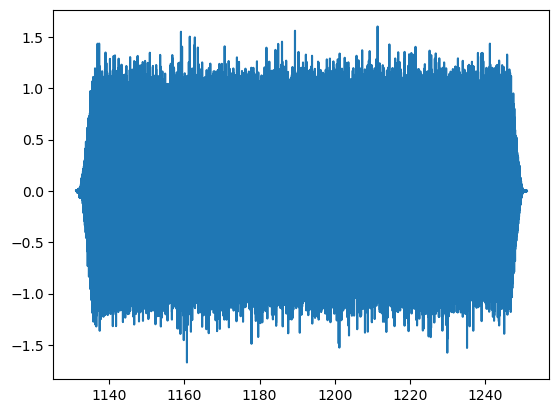

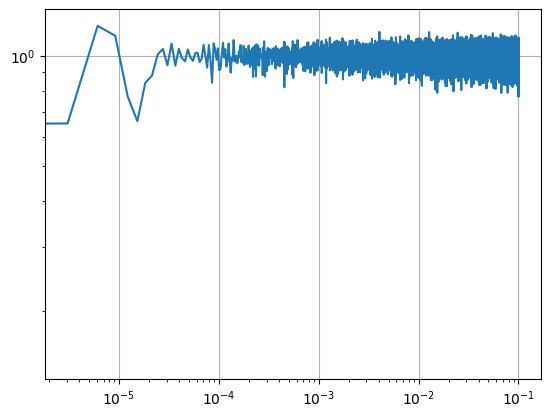

In [ ]:
plt.plot( tm/day, X_white, label="X (whitened)")
plt.show()
plt.loglog(f_psdXw, psdXw, label="X (whitened)")
plt.grid(True)
plt.show()

## 3. Compute FFT and Periodogram

The one-sided periodogram estimate of the noise Power Spectral Density $S$ is

$$\hat{S}(f_k) = \frac{2\,\Delta t}{N} \left|\tilde{n}(f_k)\right|^2$$

where $\tilde{n}$ is the FFT of the processed time series, $\Delta t$ the sampling interval and $N$ the length of the truncated data set.

In [ ]:
sp_0.fft()

(array([0.00000000e+00, 9.64506173e-08, 1.92901235e-07, ...,
        9.99998071e-02, 9.99999035e-02, 1.00000000e-01], shape=(1036801,)),
 {'X': array([ 2.30769787e-20+0.00000000e+00j,  1.80854892e-20-6.21814585e-21j,
          1.85852299e-20-9.86541014e-21j, ...,
         -2.05873833e-18-1.34242226e-17j, -2.26348183e-17-1.41758779e-17j,
         -2.42883402e-17+0.00000000e+00j], shape=(1036801,)),
  'Y': array([ 2.17601822e-20+0.00000000e+00j,  2.60389830e-20-4.20978979e-21j,
          2.40891904e-20-4.77763738e-21j, ...,
         -1.71679667e-18+5.23645556e-17j,  3.40264345e-18+1.41158860e-18j,
          1.90936244e-17+0.00000000e+00j], shape=(1036801,)),
  'Z': array([-8.31639071e-21+0.00000000e+00j, -7.84822165e-21+5.41304319e-21j,
         -7.06842640e-21+4.84850849e-21j, ...,
          2.46488955e-18-4.13113382e-17j, -1.82105585e-17+1.71659635e-17j,
         -3.01609861e-18+0.00000000e+00j], shape=(1036801,))})

In [ ]:
# Data is already normalised by laser_frequency inside process_pipeline.
# Use the new periodogram() and to_aet() methods directly.
CENTRAL_FREQ = data["metadata"]["laser_frequency"]

freq, fft_xyz = sp_0.fft()

sp_0_aet = sp_0.to_aet()
_, fft_aet = sp_0_aet.fft()

# psd_norm for reference (this is the factor baked into periodogram())
psd_norm = 2 * sp_0.dt / sp_0.N

psd_xyz = {ch: (np.abs(fft_xyz[ch]) ** 2) * psd_norm for ch in ["X", "Y", "Z"]}
psd_aet = {ch: (np.abs(fft_aet[ch]) ** 2) * psd_norm for ch in ["A", "E", "T"]}

# Mojito L1 noise estimates, normalised to fractional frequency units
noise_freqs = data["noise_estimates"]["freqs"]
noise_cov_xyz = data["noise_estimates"]["xyz"]
noise_cov_aet = data["noise_estimates"]["aet"]

l1_xyz = {
    ch: noise_cov_xyz[0][:, i, i] / CENTRAL_FREQ**2
    for i, ch in enumerate(["X", "Y", "Z"])
}
l1_aet = {
    ch: noise_cov_aet[0][:, i, i] / CENTRAL_FREQ**2
    for i, ch in enumerate(["A", "E", "T"])
}

## 4. Periodogram vs Mojito L1 Estimate

A good processing pipeline produces a periodogram (coloured lines) that traces the Mojito L1 noise model (red dashed) throughout the science band (1×10⁻⁴ to 1×10⁻¹ Hz). Potential deviations at the lowest frequencies indicate residual artefacts from filtering or insufficient trimming.

/opt/anaconda3/envs/globalfit/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/globalfit/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


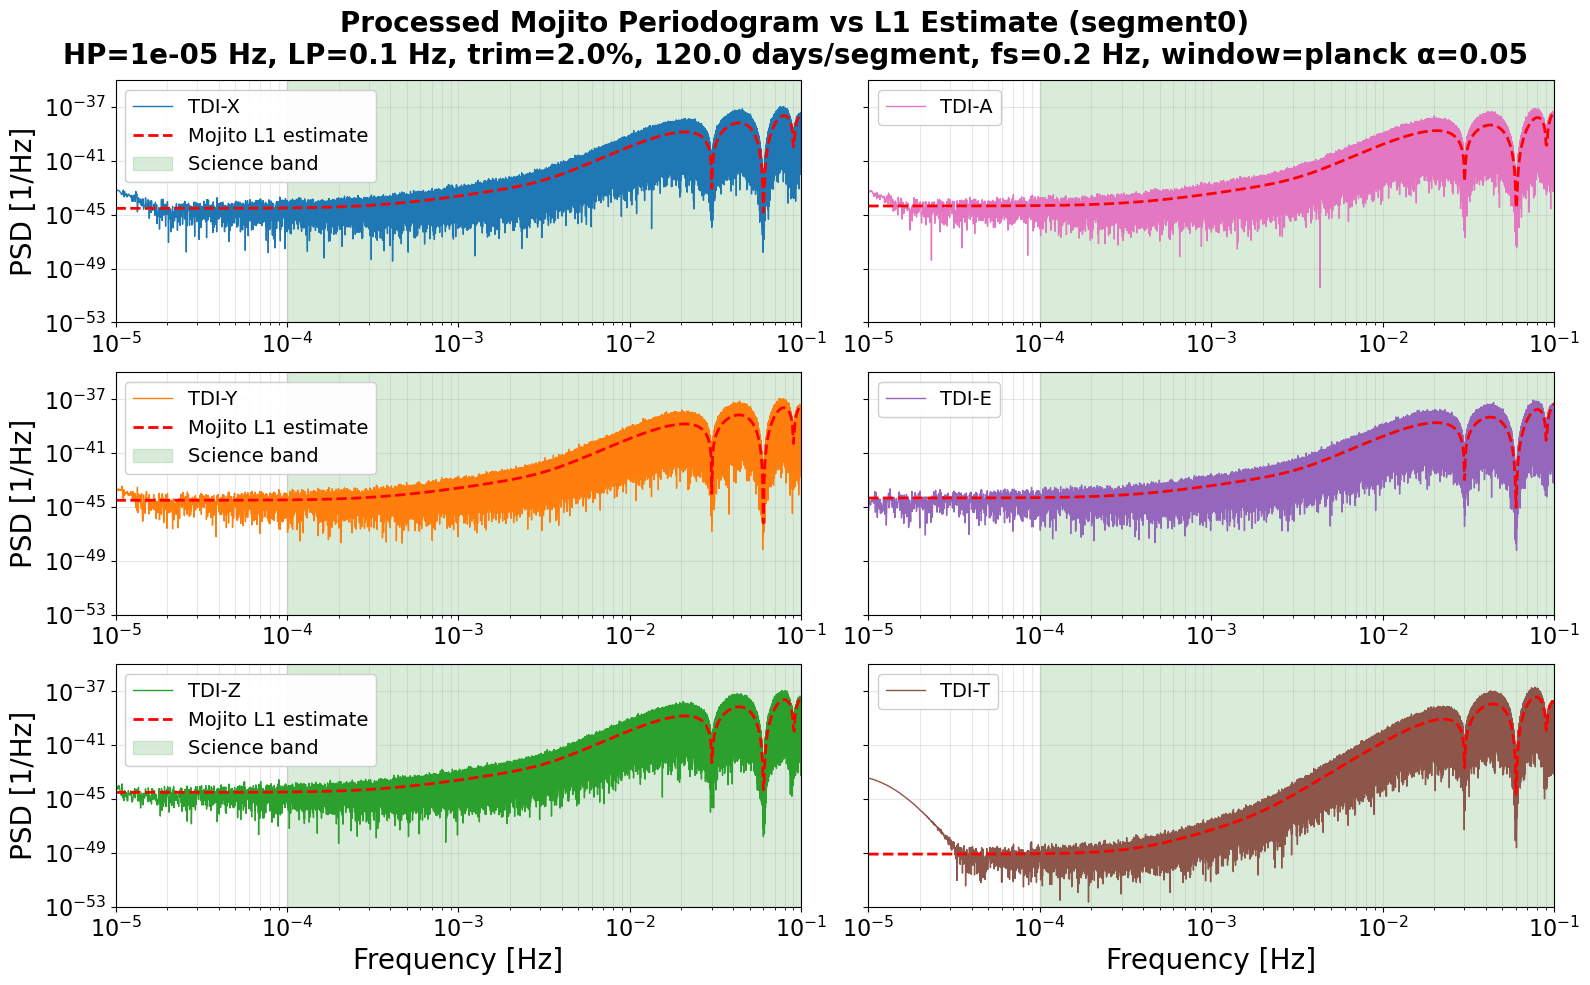

In [ ]:
nyquist = sp_0.fs / 2
xyz_colors = ["C0", "C1", "C2"]
aet_colors = ["#e377c2", "#9467bd", "#8c564b"]

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=False, sharey=True)

for i, ch in enumerate(["X", "Y", "Z"]):
    ax = axes[i, 0]
    ax.loglog(
        freq[1:],
        psd_xyz[ch][1:],
        linewidth=1.0,
        color=xyz_colors[i],
        label=f"TDI-{ch}",
    )
    ax.loglog(
        noise_freqs,
        l1_xyz[ch],
        linestyle="dashed",
        color="red",
        linewidth=2.0,
        label="Mojito L1 estimate",
    )
    ax.axvspan(1e-4, 1e-1, alpha=0.15, color="green", label="Science band")
    ax.set_xlim(1e-5, nyquist)
    ax.set_ylim(1e-53, 1e-35)
    ax.set_ylabel("PSD [1/Hz]", fontsize=20)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", fontsize=14, framealpha=0.95)
    ax.tick_params(axis="both", which="major", labelsize=16)
for i, ch in enumerate(["A", "E", "T"]):
    ax = axes[i, 1]
    ax.loglog(
        freq[1:],
        psd_aet[ch][1:],
        linewidth=1.0,
        color=aet_colors[i],
        label=f"TDI-{ch}",
    )
    ax.loglog(noise_freqs, l1_aet[ch], linestyle="dashed", color="red", linewidth=2.0)
    ax.axvspan(1e-4, 1e-1, alpha=0.15, color="green")
    ax.set_xlim(1e-5, nyquist)
    ax.set_ylim(1e-53, 1e-35)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left", fontsize=14, framealpha=0.95)
    ax.tick_params(axis="both", which="major", labelsize=16)

axes[2, 0].set_xlabel("Frequency [Hz]", fontsize=20)
axes[2, 1].set_xlabel("Frequency [Hz]", fontsize=20)

fig.suptitle(
    f"Processed Mojito Periodogram vs L1 Estimate (segment0)\n"
    f"HP={filter_kwargs['highpass_cutoff']:.0e} Hz, "
    f"LP={filter_kwargs['lowpass_cutoff']} Hz, "
    f"trim={trim_kwargs['fraction']:.1%}, "
    f"{truncate_kwargs['days']} days/segment, "
    f"fs={sp_0.fs} Hz, "
    f"window={window_kwargs['window']} α={window_kwargs.get('alpha', 'N/A')}",
    fontsize=20,
    fontweight="bold",
)
plt.tight_layout()
plt.show()